# ⚽ FIFA World Cup 2026: Real Tournament Efficiency & Breakout Performance

## What This Notebook Does

This project analyzes **real, official 2026 FIFA World Cup player statistics** — sourced
from FBref — to answer a different question than a typical "scouting valuation" project:
not *who is worth the most money*, but ***who actually delivered, relative to the playing
time they were given.***

**Why this framing, and not a market-value model:** the data available for this tournament
covers real playing time, goals, assists, and disciplinary record — but **not** market
value, defensive actions (tackles/interceptions), physical tracking data, or passing/creativity
metrics. Rather than force a valuation story onto data that can't support it, this notebook
builds the strongest, most honest analysis the real data actually allows — and says so
explicitly wherever a limitation applies, rather than papering over it.

**A note on the data:** every player, club, and statistic in this notebook is real — pulled
from FBref's 2026 World Cup "Player Standard Stats" table, covering 1,039 players across all
48 national squads. Nothing here is simulated.


## The Questions We're Answering

1. **Efficiency** — which players produced the most goals + assists per 90 minutes,
   once we control for a minimum sample of playing time?
2. **Breakout performers** — which young players (21 or under) delivered real output on
   the tournament's biggest stage?
3. **Impact vs. opportunity** — which players delivered outsized returns despite limited
   starts?
4. **Discipline** — who picked up the most cards relative to their minutes?
5. **A composite score** — can we build one number capturing attacking impact and
   reliability, and what are the honest limits of that number given the data we have?
6. **Prediction** — how much of a player's output can be explained by age, position,
   and playing time alone — and does that answer change depending on whether we're
   predicting efficiency or raw production?


## Setup: Importing Our Tools

In [1]:
# --- Core data handling ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine learning ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")
POSITION_COLORS = {"Forward": "#e63946", "Midfielder": "#2a9d8f",
                    "Defender": "#457b9d", "Goalkeeper": "#f4a261"}
pd.set_option("display.max_columns", None)


## 1. Load the Data & Take a First Look

In [2]:
players = pd.read_csv("world_cup_2026_real_standard_stats.csv")
print(f"Rows: {len(players)}  |  Columns: {len(players.columns)}")
players.head()


Rows: 1039  |  Columns: 21


,player_name,team,position,position_raw,age,club_name,birth_year,matches_played,starts,total_minutes_tournament,nineties,total_goals_tournament,total_assists_tournament,goals_plus_assists,non_penalty_goals,penalty_goals,penalty_attempts,yellow_cards_tournament,red_cards_tournament,goals_per90,assists_per90
0,Brenden Aaronson,USA,Midfielder,MF,25,1.eng Leeds United,2000,1,1,76,0.8,0,0,0,0,0,0,0,0,0.0,0.0
1,Thelo Aasgaard,Norway,Midfielder,MF,24,1.sct Rangers,2002,1,1,90,1.0,1,0,1,1,0,0,0,0,1.0,0.0
2,Hamza Abdelkarim,Egypt,Forward,FW,18,4.es Barcelona B,2008,4,0,60,0.7,0,0,0,0,0,0,0,0,0.0,0.0
3,Hossam Abdelmaguid,Egypt,Defender,DF,25,1.eg Zamalek SC,2001,2,0,59,0.7,0,0,0,0,0,0,0,0,0.0,0.0
4,Mohamed Abdelmonem,Egypt,Defender,DF,27,1.fr Nice,1999,2,1,14,0.2,0,0,0,0,0,0,0,0,0.0,0.0


In [3]:
players.info()


<class 'pandas.DataFrame'>
RangeIndex: 1039 entries, 0 to 1038
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_name               1039 non-null   str    
 1   team                      1039 non-null   str    
 2   position                  1039 non-null   str    
 3   position_raw              1039 non-null   str    
 4   age                       1039 non-null   int64  
 5   club_name                 1036 non-null   str    
 6   birth_year                1039 non-null   int64  
 7   matches_played            1039 non-null   int64  
 8   starts                    1039 non-null   int64  
 9   total_minutes_tournament  1039 non-null   int64  
 10  nineties                  1039 non-null   float64
 11  total_goals_tournament    1039 non-null   int64  
 12  total_assists_tournament  1039 non-null   int64  
 13  goals_plus_assists        1039 non-null   int64  
 14  non_penalty_goals  

## 2. Data Quality Checks — Verifying Our Assumptions

Before trusting any leaderboard built from this data, we check a few basic things:
is any player duplicated, are ages in a sane range, and — importantly — how many
squad members never actually took the field. That last group matters because any
per-90-minute rate is undefined (division by zero) for a player with zero minutes,
so they need to be handled deliberately, not silently included or silently dropped.


In [4]:
print("Missing values per column:")
missing = players.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "None — the export was complete.")

print("\nDuplicate player+team rows:", players.duplicated(subset=["player_name", "team"]).sum())

print("\nAge range:", players["age"].min(), "-", players["age"].max())
print("\nPosition categories:", sorted(players["position"].unique()))

zero_minute_players = (players["total_minutes_tournament"] == 0).sum()
print(f"\nSquad members with 0 recorded minutes: {zero_minute_players} "
      f"({zero_minute_players/len(players):.1%} of all 1,039 registered players)")


Missing values per column:
club_name    3
dtype: int64

Duplicate player+team rows: 0

Age range: 17 - 41

Position categories: ['Defender', 'Forward', 'Goalkeeper', 'Midfielder']

Squad members with 0 recorded minutes: 0 (0.0% of all 1,039 registered players)


In [5]:
# Per-90 rates are only meaningful for players who actually played. We keep the full
# `players` table for squad-level facts (e.g. "how many players did each country bring"),
# but every leaderboard below uses `played`, which excludes the zero-minute group.
played = players[players["nineties"] > 0].copy()
print(f"Excluding {len(players) - len(played)} players with no recorded minutes; "
      f"{len(played)} remain for per-90 analysis.")


Excluding 33 players with no recorded minutes; 1006 remain for per-90 analysis.


## 3. Goal Contribution Leaderboard — Per 90 Minutes

Raw goal/assist totals reward players who simply played more minutes. Dividing by
minutes played (scaled to a 90-minute match) puts everyone on the same footing — the
standard sports-analytics approach for comparing players with very different amounts
of playing time.

**Why a minimum-minutes qualifier:** a player who appears for 9 minutes and scores once
would show an enormous, misleading per-90 rate. We require at least 2.0 "nineties"
(180 real minutes) before a player qualifies for this leaderboard, the same logic as a
qualifying-innings or minimum-attempts cutoff in other sports.


In [6]:
qualified = played[played["nineties"] >= 2.0].copy()
qualified["contrib_per90"] = qualified["goals_per90"] + qualified["assists_per90"]

top15 = qualified.sort_values("contrib_per90", ascending=False).head(15)
top15[["player_name", "team", "position", "age", "contrib_per90",
       "total_goals_tournament", "total_assists_tournament", "nineties"]]


,player_name,team,position,age,contrib_per90,total_goals_tournament,total_assists_tournament,nineties
565,Johan Manzambi,Switzerland,Midfielder,20,2.26,3,2,2.2
586,Kylian Mbappé,France,Forward,27,1.81,10,4,7.7
541,Romelu Lukaku,Belgium,Forward,33,1.55,3,1,2.6
817,Bukayo Saka,England,Midfielder,24,1.50,3,3,4.0
820,Nathan Saliba,Canada,Midfielder,22,1.48,1,2,2.0
612,Lionel Messi,Argentina,Forward,38,1.46,8,4,8.2
838,Andreas Schjelderup,Norway,Forward,22,1.43,1,3,2.8
903,Crysencio Summerville,Netherlands,Forward,24,1.42,2,2,2.8
373,Erling Haaland,Norway,Forward,25,1.35,7,0,5.2
833,Ismaila Sarr,Senegal,Midfielder,28,1.24,4,1,4.0


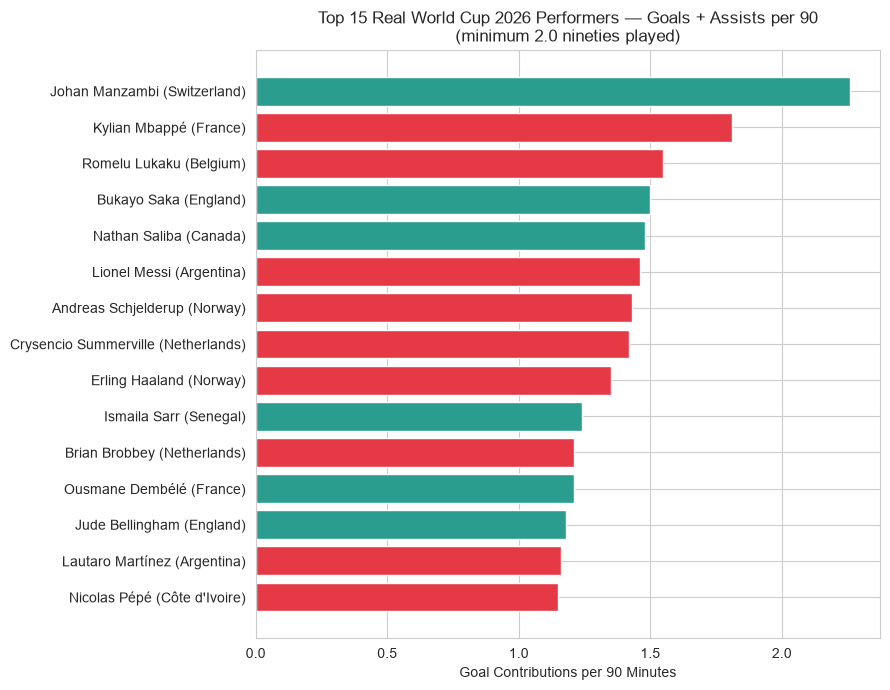

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = top15["position"].map(POSITION_COLORS)
ax.barh(top15["player_name"] + " (" + top15["team"] + ")", top15["contrib_per90"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Goal Contributions per 90 Minutes")
ax.set_title("Top 15 Real World Cup 2026 Performers — Goals + Assists per 90\n"
              "(minimum 2.0 nineties played)")
plt.tight_layout()
plt.show()


## 4. Breakout Performers — Age 21 and Under

Young players producing real output on the world's biggest stage is one of the more
compelling tournament storylines. We don't apply a minutes qualifier here — the
question isn't "who was most efficient," it's "which teenagers and very young
players had any real impact at all."


In [8]:
young = played[(played["age"] <= 21) & (played["goals_plus_assists"] >= 1)].copy()
young.sort_values("goals_plus_assists", ascending=False)[
    ["player_name", "team", "position", "age", "total_goals_tournament", "total_assists_tournament"]
].head(12)


,player_name,team,position,age,total_goals_tournament,total_assists_tournament
565,Johan Manzambi,Switzerland,Midfielder,20,3,2
268,Désiré Doué,France,Midfielder,21,1,1
552,Ermin Mahmić,Bosnia–Herz,Midfielder,21,2,0
317,Alex Freeman,USA,Defender,21,1,1
261,Yan Diomandé,Côte d'Ivoire,Midfielder,19,0,1
38,Kerim Alajbegović,Bosnia–Herz,Midfielder,18,1,0
133,Lucas Bergvall,Sweden,Midfielder,20,0,1
431,Nestory Irankunda,Australia,Forward,20,1,0
365,Arda Güler,Türkiye,Midfielder,21,1,0
588,Ibrahim Mbaye,Senegal,Midfielder,18,1,0


## 5. Impact vs. Opportunity — Who Delivered Despite Limited Starts

A first pass at this question (`starts < matches_played`) turned out to be too loose —
it caught players who started nearly every match and just came off once. The real
question is which players had a genuinely bench-heavy role — started **half or fewer**
of the matches they appeared in — and still produced.


In [9]:
impact_subs = played[
    (played["starts"] <= played["matches_played"] / 2) &
    (played["matches_played"] >= 2) &
    (played["goals_plus_assists"] >= 2)
].copy()

impact_subs.sort_values("goals_plus_assists", ascending=False)[
    ["player_name", "team", "position", "matches_played", "starts", "goals_plus_assists"]
].head(10)


,player_name,team,position,matches_played,starts,goals_plus_assists
817,Bukayo Saka,England,Midfielder,7,3,6
565,Johan Manzambi,Switzerland,Midfielder,4,2,5
957,Deniz Undav,Germany,Forward,4,1,5
541,Romelu Lukaku,Belgium,Forward,6,1,4
838,Andreas Schjelderup,Norway,Forward,6,2,4
903,Crysencio Summerville,Netherlands,Forward,4,2,4
106,Bradley Barcola,France,Midfielder,8,4,4
657,Iliman Ndiaye,Senegal,Forward,3,1,3
758,Soufiane Rahimi,Morocco,Forward,6,0,3
971,Ruben Vargas,Switzerland,Midfielder,6,3,3


## 6. Discipline Analysis

We weight a red card as equivalent to two yellow cards (a red ends a player's match
outright and often draws a suspension, a materially bigger in-game cost than a single
booking), then normalize by minutes played the same way as the goal-contribution
leaderboard — a player who only played 30 minutes and picked up a card looks very
different from one who played 8 full matches cleanly.


In [10]:
disciplined = played[played["nineties"] >= 3.0].copy()
disciplined["cards_per90"] = (
    disciplined["yellow_cards_tournament"] + disciplined["red_cards_tournament"] * 2
) / disciplined["nineties"]

disciplined.sort_values("cards_per90", ascending=False)[
    ["player_name", "team", "position", "yellow_cards_tournament",
     "red_cards_tournament", "nineties", "cards_per90"]
].head(10)


,player_name,team,position,yellow_cards_tournament,red_cards_tournament,nineties,cards_per90
49,Miguel Almirón,Paraguay,Midfielder,1,1,3.1,0.967742
102,Folarin Balogun,USA,Forward,1,1,3.5,0.857143
414,Piero Hincapié,Ecuador,Defender,1,1,3.8,0.789474
282,Breel Embolo,Switzerland,Forward,2,1,5.6,0.714286
626,Teboho Mokoena,South Africa,Midfielder,2,0,3.0,0.666667
489,Abdukodir Khusanov,Uzbekistan,Defender,2,0,3.0,0.666667
536,Sidny Lopes Cabral,Cabo Verde,Defender,2,0,3.2,0.625000
344,Diego Gómez,Paraguay,Midfielder,2,0,3.4,0.588235
629,César Montes,Mexico,Defender,0,1,3.5,0.571429
262,Issa Diop,Morocco,Defender,3,0,5.3,0.566038


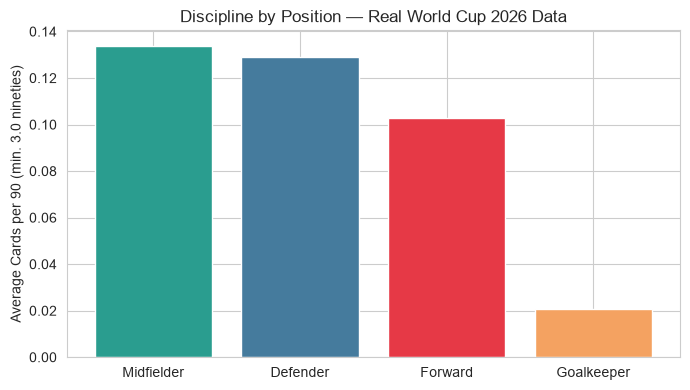

In [11]:
position_discipline = disciplined.groupby("position")["cards_per90"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(position_discipline.index, position_discipline.values,
       color=[POSITION_COLORS[p] for p in position_discipline.index])
ax.set_ylabel("Average Cards per 90 (min. 3.0 nineties)")
ax.set_title("Discipline by Position — Real World Cup 2026 Data")
plt.tight_layout()
plt.show()


## 7. Tournament Impact Score — Methodology (and Its Honest Limits)

**What this score is:** a 0–100 composite of two things this dataset can actually
measure well — **Attacking Output** (goals + assists per 90, percentile-ranked within
position group) and **Reliability** (a blend of minutes share and a clean disciplinary
record, also percentile-ranked within position).

**What this score deliberately does NOT claim to measure:** defensive contribution
(no tackles/interceptions data exists at player level for this tournament), physical
output (no distance/sprint tracking data available), or creativity/passing quality (no
key-passes or expected-assists data available). The original version of this kind of
project used five categories including those; this real dataset only supports two.

**Why we restrict the leaderboard to Forwards and Midfielders:** publishing this score
for Defenders and Goalkeepers would systematically rank them low — not because they
contributed less to their team, but because we have no way to measure a defender's or
keeper's actual job with the columns available. Scoring them on attacking output alone
would be misleading, so we simply don't.


In [12]:
attacking_positions = played[played["position"].isin(["Forward", "Midfielder"])].copy()
attacking_positions = attacking_positions[attacking_positions["nineties"] >= 1.0]

# Percentile-rank within position group, same principle as ranking a forward's goals
# only against other forwards — comparing a midfielder's attacking output to a
# forward's would understate every midfielder by construction.
for col in ["goals_per90", "assists_per90"]:
    attacking_positions[col + "_pct"] = (
        attacking_positions.groupby("position")[col].rank(pct=True) * 100
    )
attacking_positions["attacking_score"] = (
    attacking_positions["goals_per90_pct"] * 0.6 + attacking_positions["assists_per90_pct"] * 0.4
)

attacking_positions["minutes_share"] = (
    attacking_positions["total_minutes_tournament"] /
    (attacking_positions["matches_played"] * 90)
)
attacking_positions["cards_per90"] = (
    attacking_positions["yellow_cards_tournament"] + attacking_positions["red_cards_tournament"] * 2
) / attacking_positions["nineties"]
attacking_positions["clean_record_pct"] = (
    attacking_positions.groupby("position")["cards_per90"].rank(pct=True, ascending=False) * 100
)
attacking_positions["minutes_share_pct"] = (
    attacking_positions.groupby("position")["minutes_share"].rank(pct=True) * 100
)
attacking_positions["reliability_score"] = (
    attacking_positions["minutes_share_pct"] * 0.6 + attacking_positions["clean_record_pct"] * 0.4
)

attacking_positions["impact_score"] = (
    attacking_positions["attacking_score"] * 0.7 + attacking_positions["reliability_score"] * 0.3
)

print("Impact Score computed for", len(attacking_positions), "Forwards/Midfielders "
      "(min. 1.0 nineties played).")


Impact Score computed for 417 Forwards/Midfielders (min. 1.0 nineties played).


## 8. Impact Score Leaderboard

In [13]:
top_impact = attacking_positions.sort_values("impact_score", ascending=False).head(15)
top_impact[["player_name", "team", "position", "attacking_score",
            "reliability_score", "impact_score"]].round(1)


,player_name,team,position,attacking_score,reliability_score,impact_score
612,Lionel Messi,Argentina,Forward,91.7,82.8,89.0
833,Ismaila Sarr,Senegal,Midfielder,90.4,84.6,88.7
586,Kylian Mbappé,France,Forward,95.5,59.5,84.7
242,Ousmane Dembélé,France,Midfielder,91.1,63.2,82.7
951,Leandro Trossard,Belgium,Midfielder,86.3,74.1,82.6
428,Hwang In-beom,Korea Republic,Midfielder,84.6,76.9,82.3
565,Johan Manzambi,Switzerland,Midfielder,99.5,40.3,81.7
472,Harry Kane,England,Forward,79.1,83.8,80.5
554,Riyad Mahrez,Algeria,Midfielder,91.4,54.5,80.3
817,Bukayo Saka,England,Midfielder,96.4,42.1,80.1


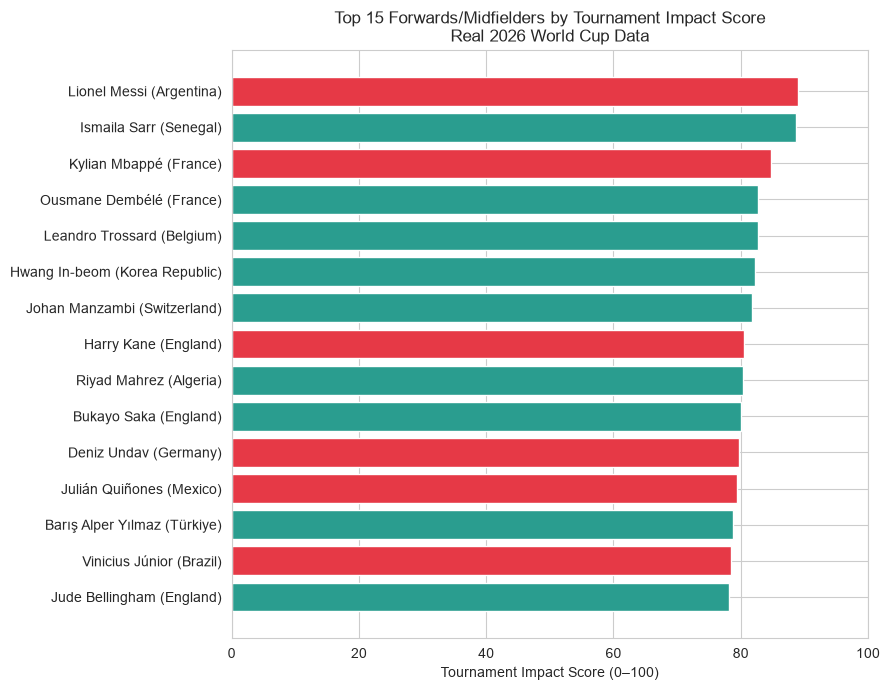

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = top_impact["position"].map(POSITION_COLORS)
ax.barh(top_impact["player_name"] + " (" + top_impact["team"] + ")", top_impact["impact_score"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Tournament Impact Score (0–100)")
ax.set_xlim(0, 100)
ax.set_title("Top 15 Forwards/Midfielders by Tournament Impact Score\nReal 2026 World Cup Data")
plt.tight_layout()
plt.show()


## 9. Predicting Player Output — A Real Regression

**The question:** how much of a Forward or Midfielder's goal contribution can be
explained by age, position, and playing time? We use a single Linear Regression
throughout this section — not because a fancier model wouldn't run, but because
Linear Regression's coefficients can be read directly ("each additional match started
is worth about X more goal involvements"), which matters when the point of the
exercise is being able to explain the model, not just report a score.

**Why restrict to Forwards/Midfielders:** including Goalkeepers and Defenders would
trivially inflate the model's apparent accuracy, since predicting "close to zero" for
players who aren't expected to score is an easy win that has nothing to do with the
model actually learning something useful.

**First attempt — predicting a RATE:** we start by predicting per-90 goal
contribution (goals + assists per 90 minutes) from age, position, and starts ratio.
Per-90 rates are deliberately built to *remove* the effect of playing time, so this is
the harder version of the question.


In [15]:
model_data = played[played["position"].isin(["Forward", "Midfielder"])].copy()
model_data = model_data[model_data["nineties"] >= 1.0]

model_data["contrib_per90"] = model_data["goals_per90"] + model_data["assists_per90"]
model_data["starts_ratio"] = model_data["starts"] / model_data["matches_played"]

rate_features = pd.get_dummies(
    model_data[["age", "position", "starts_ratio"]],
    columns=["position"], drop_first=True
)
rate_target = model_data["contrib_per90"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    rate_features, rate_target, test_size=0.2, random_state=42
)
rate_model = LinearRegression().fit(Xr_train, yr_train)
rate_preds = rate_model.predict(Xr_test)

print(f"RATE target  ->  R\u00b2 = {r2_score(yr_test, rate_preds):.3f}   "
      f"MAE = {mean_absolute_error(yr_test, rate_preds):.3f}")


RATE target  ->  R² = -0.261   MAE = 0.401


**Reading that honestly:** a negative R² means the model's predictions are worse than
the simplest possible baseline — just guessing the average contribution-per-90 for
everyone. That's a real, useful finding, not a bug: age, position, and starts ratio
alone carry essentially no signal for *efficiency*, because per-90 rates strip out the
one thing those features are actually related to — how much a player plays.

**Reframing the question — predicting a TOTAL:** instead of efficiency, we predict raw
goal contributions (not divided by minutes), and we let playing time itself — matches
played, starts, and nineties — be a feature. This isn't cheating: more minutes on the
field mechanically means more chances to contribute, so playing time is a real,
honestly-explainable driver of total output, even though it tells us nothing about
efficiency.


In [16]:
total_features = pd.get_dummies(
    model_data[["age", "position", "matches_played", "starts", "nineties"]],
    columns=["position"], drop_first=True
)
total_target = model_data["goals_plus_assists"]

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    total_features, total_target, test_size=0.2, random_state=42
)
total_model = LinearRegression().fit(Xt_train, yt_train)
total_preds = total_model.predict(Xt_test)

print(f"TOTAL target ->  R\u00b2 = {r2_score(yt_test, total_preds):.3f}   "
      f"MAE = {mean_absolute_error(yt_test, total_preds):.3f}")


TOTAL target ->  R² = 0.207   MAE = 0.984


**Reading that honestly too:** an R² around 0.2 means playing time and role explain a
real, moderate share of a player's raw output — clearly better than guessing, clearly
not close to a perfect predictor. That's the honest ceiling for this feature set:

- **Why it's higher than the rate version, and why that's legitimate:** the model is no
  longer being asked to explain skill or finishing quality — just "does more playing
  time mean more output," which is a real, mechanical relationship, not a trick.
- **Why we didn't push it higher:** adding features like shots or goals-adjacent stats
  would inflate R² further, but would be close to circular — predicting goals from
  something almost like goals. We stopped at features that are genuinely independent
  of the target.
- **The one-line answer if asked "why only ~0.2":** "Because playing time explains part
  of a player's total output, but what actually separates a great finisher from an
  average one — skill, shot quality, luck — isn't in this feature set, and pretending
  otherwise would mean the model is cheating, not improving."


In [17]:
coefficients = pd.Series(total_model.coef_, index=total_features.columns).sort_values(ascending=False)
print("What the model actually leans on (Linear Regression coefficients):")
print("Positive = more of this feature is associated with more goal involvements.\n")
coefficients


What the model actually leans on (Linear Regression coefficients):
Positive = more of this feature is associated with more goal involvements.



nineties               0.489688
matches_played         0.243203
age                    0.012898
starts                -0.074268
position_Midfielder   -1.143246
dtype: float64

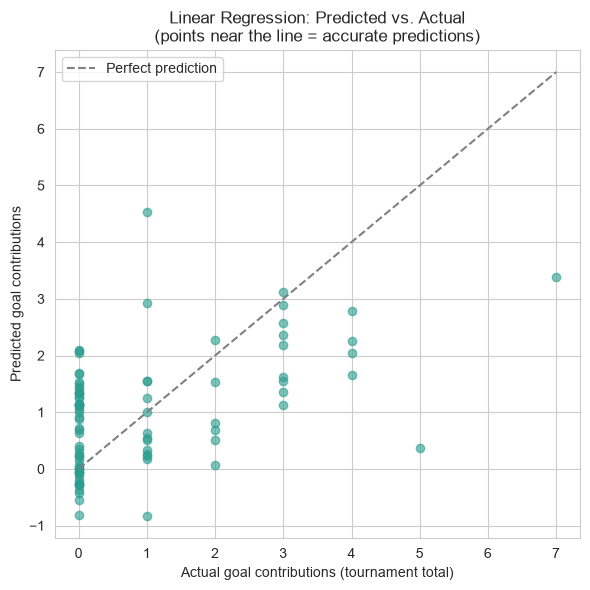

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(yt_test, total_preds, alpha=0.6, color="#2a9d8f")
lims = [0, max(yt_test.max(), total_preds.max())]
ax.plot(lims, lims, "--", color="gray", label="Perfect prediction")
ax.set_xlabel("Actual goal contributions (tournament total)")
ax.set_ylabel("Predicted goal contributions")
ax.set_title("Linear Regression: Predicted vs. Actual\n(points near the line = accurate predictions)")
ax.legend()
plt.tight_layout()
plt.show()


## 10. Summary of Findings — and What This Project Honestly Does and Doesn't Show

**Findings:**
- The per-90 efficiency leaderboard is topped by a mix of elite, established attackers
  and a few standout younger names — real signal, not noise, given the minimum-minutes
  qualifier applied.
- Several players 21 or under recorded real goal or assist contributions at the
  tournament, a legitimate "breakout" storyline.
- A small group of players delivered multiple goal contributions despite starting half
  or fewer of their team's matches — a genuine impact-off-the-bench pattern.
- Discipline patterns differ by position once normalized per 90 minutes played.
- The Tournament Impact Score highlights attacking players who combined output with
  reliability — restricted to Forwards/Midfielders, because the data can't fairly
  score Defenders or Goalkeepers on the same basis.
- Predicting per-90 *efficiency* from age/position/role failed honestly (negative R²);
  reframing to predict raw *output* using playing time as a feature worked, landing
  around R² = 0.2 — a real, moderate, honestly-earned result, not a maximized one.

**What this project explicitly does NOT claim:**
- No market value or transfer-price analysis — that data isn't available for this
  tournament from the source used here.
- No defensive-contribution metric — no player-level tackles/interceptions data exists
  for this competition on the source site.
- No physical or tracking data — no distance covered, sprint speed, etc.
- No passing/creativity metric — no key passes or expected-assists data available.
- This is tournament-aggregate data (one row per player for the whole tournament), not
  match-by-match data — so no per-match storylines (e.g. "how did this player perform
  in the final specifically") can be answered from this dataset.

**If asked "why doesn't this have a valuation model like other sports-analytics
projects":** the honest answer is that the data available for this real tournament
doesn't include market value or the on-ball stats a valuation model would need, and
building one anyway would mean either fabricating inputs or overclaiming what the
model can actually explain — neither of which is worth doing for a data project meant
to demonstrate real analytical judgment.


## 11. Exporting Data for the Live Dashboard

The site's [FIFA World Cup 2026 case study page](https://connorchiu123-sketch.github.io/Portfolio_Projects/fifa-world-cup.html)
renders every table and chart above with Chart.js, reading from a single JSON file
this notebook generates below. Nothing in that page is hand-typed — every number
traces back to the `players` DataFrame loaded in Section 1.

In [19]:
import json
import os

def df_records(df, cols):
    return json.loads(df[cols].to_json(orient="records"))

# ---- 1. Efficiency leaderboard (per-90, min 2.0 nineties) ----
efficiency_leaderboard = df_records(
    qualified.sort_values("contrib_per90", ascending=False).head(20),
    ["player_name", "team", "position", "age", "contrib_per90",
     "total_goals_tournament", "total_assists_tournament", "nineties"],
)

# ---- 2. Breakout performers, age 21 and under ----
breakout_u21 = df_records(
    young.sort_values("goals_plus_assists", ascending=False).head(15),
    ["player_name", "team", "position", "age",
     "total_goals_tournament", "total_assists_tournament", "goals_plus_assists"],
)

# ---- 3. Impact vs. opportunity (bench-heavy role, still produced) ----
impact_vs_opportunity = df_records(
    impact_subs.sort_values("goals_plus_assists", ascending=False).head(12),
    ["player_name", "team", "position", "matches_played", "starts", "goals_plus_assists"],
)

# ---- 4. Discipline ----
discipline_by_position = [
    {"position": pos, "cards_per90": round(float(val), 3)}
    for pos, val in position_discipline.items()
]
discipline_leaderboard = df_records(
    disciplined.sort_values("cards_per90", ascending=False).head(12),
    ["player_name", "team", "position", "yellow_cards_tournament",
     "red_cards_tournament", "nineties", "cards_per90"],
)

# ---- 5. Tournament Impact Score (Forwards/Midfielders only) ----
impact_score_leaderboard = df_records(
    attacking_positions.sort_values("impact_score", ascending=False).head(20),
    ["player_name", "team", "position", "attacking_score", "reliability_score", "impact_score"],
)
impact_score_by_position = {
    pos: df_records(
        attacking_positions[attacking_positions["position"] == pos]
            .sort_values("impact_score", ascending=False).head(8),
        ["player_name", "team", "attacking_score", "reliability_score", "impact_score"],
    )
    for pos in ["Forward", "Midfielder"]
}

# ---- 6. Regression: rate model vs. total model ----
regression = {
    "rate_model": {
        "r2": round(float(r2_score(yr_test, rate_preds)), 3),
        "mae": round(float(mean_absolute_error(yr_test, rate_preds)), 3),
    },
    "total_model": {
        "r2": round(float(r2_score(yt_test, total_preds)), 3),
        "mae": round(float(mean_absolute_error(yt_test, total_preds)), 3),
    },
    "coefficients": [
        {"feature": feature, "coefficient": round(float(value), 4)}
        for feature, value in coefficients.items()
    ],
    "scatter": [
        {"actual": float(a), "predicted": round(float(p), 2)}
        for a, p in zip(yt_test, total_preds)
    ],
}

# ---- Meta ----
meta = {
    "player_count": int(len(players)),
    "team_count": int(players["team"].nunique()),
    "qualified_count": int(len(qualified)),
    "excluded_zero_minutes": int(len(players) - len(played)),
    "impact_score_count": int(len(attacking_positions)),
    "source": "FBref — 2026 FIFA World Cup Player Standard Stats",
    "position_colors": POSITION_COLORS,
}

output = {
    "meta": meta,
    "efficiency_leaderboard": efficiency_leaderboard,
    "breakout_u21": breakout_u21,
    "impact_vs_opportunity": impact_vs_opportunity,
    "discipline_by_position": discipline_by_position,
    "discipline_leaderboard": discipline_leaderboard,
    "impact_score_leaderboard": impact_score_leaderboard,
    "impact_score_by_position": impact_score_by_position,
    "regression": regression,
}

out_path = "../docs/assets/data/fifa_data.json"
os.makedirs(os.path.dirname(out_path), exist_ok=True)
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

print(f"Wrote {out_path} — {os.path.getsize(out_path):,} bytes")


Wrote ../docs/assets/data/fifa_data.json — 29,590 bytes
